# 05 - Modeling: Next-Day Demand Forecast
Baseline (naive lag-7) vs Linear Regression vs Random Forest vs XGBoost, evaluated on a **time-based** train/test split (no shuffling - the test set is strictly the most recent ~20% of days) plus `TimeSeriesSplit` cross-validation on the training set.

In [1]:
import sys; sys.path.insert(0, '../src')
from data_preprocessing import run as preprocess
from feature_engineering import run as engineer
from modeling import run as model_run

df, _ = preprocess('../data/coffee_shop_sales.csv')
feat = engineer(df)
out = model_run(feat)
out['test_results']

,model,MAE,RMSE,MAPE_%
0,Baseline (naive: lag_7),16.527,28.314,50.53
1,Linear Regression,11.900,19.759,45.10
2,Random Forest,10.459,19.225,31.59
3,XGBoost,10.397,18.342,32.93


In [2]:
out['cv_mae_by_model']

{'Linear Regression': 9.89455794273,
 'Random Forest': 8.873790605937298,
 'XGBoost': 9.217272472381591}

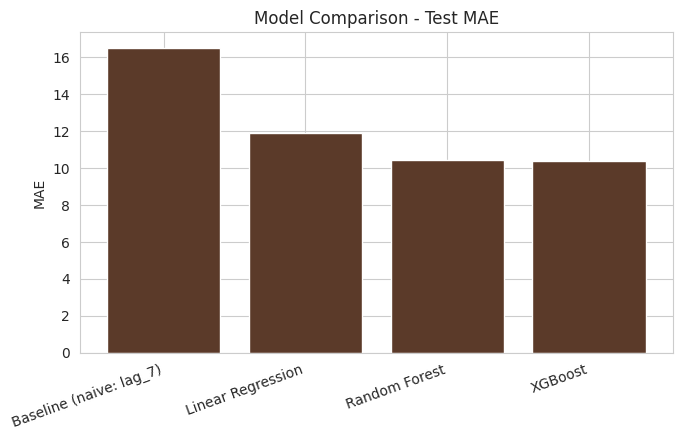

In [3]:
from visualization import plot_model_comparison, plot_feature_importance
plot_model_comparison(out['test_results']);

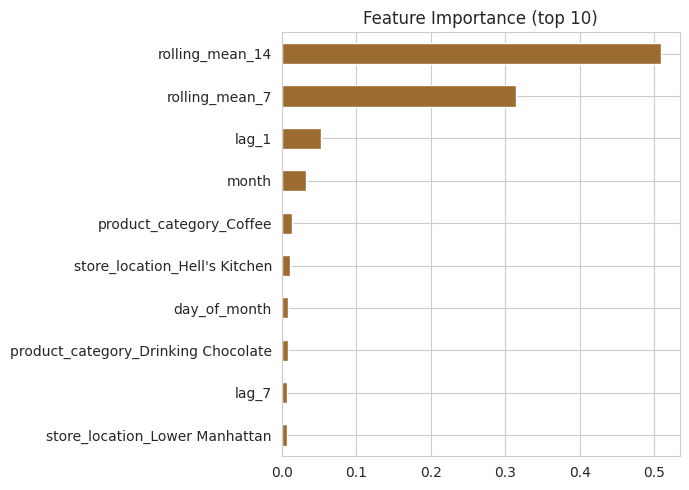

In [4]:
plot_feature_importance(out['feature_importance_xgb']);

**Result:** XGBoost cuts test MAE from 16.5 units/day (naive baseline) to 10.4 units/day (~37% error reduction); Random Forest is close behind. The two rolling-mean features dominate feature importance - recent demand momentum matters far more than the calendar.

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


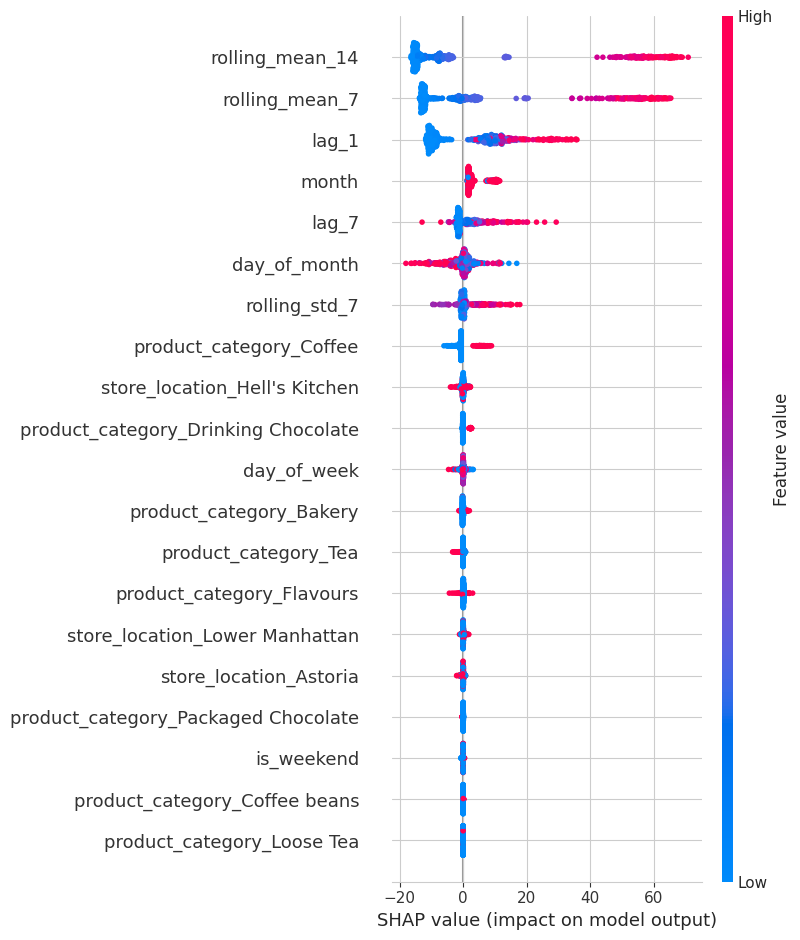

In [5]:
import shap
xgb_model = out['fitted_models']['xgboost']
X_test = out['X_test']
explainer = shap.TreeExplainer(xgb_model)
sample = X_test.sample(min(500, len(X_test)), random_state=42)
shap_values = explainer(sample)
shap.summary_plot(shap_values, sample, show=True)